# 06 -- Multi-Dataset Evaluation: 70/10/20 Writer Split

**Change from v5**: All 4 datasets now get a writer-level 70/10/20 split.
- CEDAR, GPDS150, SigComp2011: 70% train / 10% val / 20% **test**
- SigComp2009: all training (no forgeries available for EER evaluation)

**Evaluation**: separate EER per dataset + combined.


In [1]:
import sys, re, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models

from sklearn import metrics as sk_metrics
from sklearn.decomposition import PCA

def _find_project_root(start):
    for p in [start] + list(start.parents):
        if (p / '.git').exists() or (p / 'requirements.txt').exists():
            return p
    raise RuntimeError(f'Cannot find project root from {start}')

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.seed import set_seed
from src.metrics.verification import compute_metrics

SEED     = 42
set_seed(SEED)
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DS_ROOT  = PROJECT_ROOT / 'datasets'
EMB_DIM  = 256
K_SUB    = 3       # SubCenterArcFace sub-centres per writer
IMG_SIZE = 224
BATCH    = 64
N_P1     = 30      # Phase 1 epochs
N_P2     = 15      # Phase 2 epochs
N_P3     = 10      # Phase 3 epochs
WARMUP   = 3       # LR warmup epochs

print('Device      :', DEVICE)
print('Dataset root:', DS_ROOT)

Device      : cuda
Dataset root: /home/jovyan/vault/datasets


---
## Section 1 -- Dataset Scanners

**SigComp2011 update**: now scans BOTH `Offline Genuine/` AND `Offline Forgeries/`
so that the 4 held-out test writers have forgeries available for EER computation.


In [2]:
def scan_cedar(root):
    root  = Path(root)
    pat_o = re.compile(r'^original_(\d+)_(\d+)\.png$',  re.I)
    pat_f = re.compile(r'^forgeries_(\d+)_(\d+)\.png$', re.I)
    rows  = []
    for fp in (root/'full_org').iterdir():
        m = pat_o.match(fp.name)
        if m: rows.append({'path':str(fp),'writer_uid':f'cedar_{int(m.group(1)):03d}','label':'genuine','dataset':'cedar'})
    for fp in (root/'full_forg').iterdir():
        m = pat_f.match(fp.name)
        if m: rows.append({'path':str(fp),'writer_uid':f'cedar_{int(m.group(1)):03d}','label':'forgery','dataset':'cedar'})
    return pd.DataFrame(rows, columns=['path','writer_uid','label','dataset'])

def scan_gpds150(root):
    """Scan train/genuine and train/forge flat dirs (all 150 writers, fast)."""
    root  = Path(root)
    pat_g = re.compile(r'^c-(\d+)-',  re.I)
    pat_f = re.compile(r'^cf-(\d+)-', re.I)
    rows  = []
    train_gen  = root / 'train' / 'genuine'
    train_forg = root / 'train' / 'forge'
    if train_gen.exists():
        for fp in train_gen.iterdir():
            m = pat_g.match(fp.name)
            if m: rows.append({'path':str(fp),'writer_uid':f'gpds_{int(m.group(1)):03d}','label':'genuine','dataset':'gpds150'})
    if train_forg.exists():
        for fp in train_forg.iterdir():
            m = pat_f.match(fp.name)
            if m: rows.append({'path':str(fp),'writer_uid':f'gpds_{int(m.group(1)):03d}','label':'forgery','dataset':'gpds150'})
    return pd.DataFrame(rows, columns=['path','writer_uid','label','dataset'])

def scan_sigcomp2011(root):
    """Scan genuine AND forgery images from the training set."""
    root = Path(root)
    pat  = re.compile(r'^(\d+)_', re.I)
    rows = []
    print(f'scan_sigcomp2011: root={root}  exists={root.exists()}')
    if not root.exists():
        print(f'  ERROR: root path not found. Contents of parent: {list(root.parent.iterdir()) if root.parent.exists() else "parent also missing"}')
        return pd.DataFrame(columns=['path','writer_uid','label','dataset'])
    # Try known sub-path first, then fall back to searching for OfflineSignatures anywhere under root
    base = root / 'OfflineSignatures'
    if not base.exists():
        # search one level deeper
        candidates = [d for d in root.iterdir() if d.is_dir()]
        print(f'  OfflineSignatures not at {base}, root contents: {[d.name for d in candidates]}')
        deeper = [d / 'OfflineSignatures' for d in candidates if (d / 'OfflineSignatures').exists()]
        if deeper:
            base = deeper[0]
            print(f'  Found OfflineSignatures at: {base}')
        else:
            print('  ERROR: cannot find OfflineSignatures directory.')
            return pd.DataFrame(columns=['path','writer_uid','label','dataset'])
    for lang, prefix in [('Dutch','sc11d'), ('Chinese','sc11c')]:
        train_dir = base / lang / 'TrainingSet'
        if not train_dir.exists():
            print(f'  skipping lang={lang}, TrainingSet not found at {train_dir}')
            continue
        for label_folder, label_tag in [('Offline Genuine','genuine'), ('Offline Forgeries','forgery')]:
            folder = train_dir / label_folder
            if not folder.exists():
                print(f'  skipping: {folder}')
                continue
            found = 0
            for fp in folder.iterdir():
                m = pat.match(fp.name)
                if m:
                    rows.append({'path':str(fp),'writer_uid':f'{prefix}_{int(m.group(1)):03d}',
                                 'label':label_tag,'dataset':'sc11'})
                    found += 1
            print(f'  {lang:7s} {label_folder}: {found} files')
    return pd.DataFrame(rows, columns=['path','writer_uid','label','dataset'])

def scan_sigcomp2009(root):
    root = Path(root)
    if not root.exists():
        print(f'WARNING scan_sigcomp2009: path not found: {root}')
        return pd.DataFrame(columns=['path','writer_uid','label','dataset'])
    pat  = re.compile(r'^NISDCC-(\d+)_', re.I)
    rows = []
    inner = root / 'NISDCC-offline-all-001-051-6g' / 'NISDCC-offline-all-001-051-6g'
    target = inner if inner.exists() else root
    for fp in target.iterdir():
        if not fp.is_file(): continue
        m = pat.match(fp.name)
        if m:
            rows.append({'path':str(fp),'writer_uid':f'sc09_{int(m.group(1)):03d}',
                         'label':'genuine','dataset':'sc09'})
    return pd.DataFrame(rows, columns=['path','writer_uid','label','dataset'])

df_cedar = scan_cedar(DS_ROOT / 'CEDAR')
df_gpds  = scan_gpds150(DS_ROOT / 'GPDS150')
df_sc11  = scan_sigcomp2011(DS_ROOT / 'sigComp2011-trainingSet')
df_sc09  = scan_sigcomp2009(DS_ROOT / 'SigComp2009-training')

for name, df in [('CEDAR',df_cedar),('GPDS150',df_gpds),('SigComp2011',df_sc11),('SigComp2009',df_sc09)]:
    if df.empty:
        print(f'{name:12s}  *** EMPTY -- check path / directory structure ***')
        continue
    writers = df['writer_uid'].nunique()
    gen  = (df['label']=='genuine').sum()
    forg = (df['label']=='forgery').sum()
    print(f'{name:12s}  writers={writers:3d}  genuine={gen:5d}  forgery={forg:5d}')


scan_sigcomp2011: root=/home/jovyan/vault/datasets/sigComp2011-trainingSet  exists=True
  OfflineSignatures not at /home/jovyan/vault/datasets/sigComp2011-trainingSet/OfflineSignatures, root contents: ['trainingSet']
  Found OfflineSignatures at: /home/jovyan/vault/datasets/sigComp2011-trainingSet/trainingSet/OfflineSignatures
  Dutch   Offline Genuine: 239 files
  Dutch   Offline Forgeries: 123 files
  Chinese Offline Genuine: 235 files
  Chinese Offline Forgeries: 340 files
CEDAR         writers= 55  genuine= 1320  forgery= 1320
GPDS150       writers=150  genuine= 2400  forgery= 2400
SigComp2011   writers= 80  genuine=  474  forgery=  463
SigComp2009   writers= 43  genuine= 1898  forgery=    0


---
## Section 2 -- Writer Split (70 / 10 / 20)

Each dataset (except SigComp2009) is split by **writer ID** at 70/10/20.
SigComp2009 has no forgeries — all 43 writers go to training only.

Split is deterministic (seed=42). No image from a writer appears in more than one split.


In [3]:
def split_writers(writer_uids, seed=42, train_frac=0.70, val_frac=0.10):
    arr = np.array(sorted(writer_uids))
    rng = np.random.default_rng(seed)
    rng.shuffle(arr)
    n    = len(arr)
    n_tr = int(round(n * train_frac))
    n_v  = int(round(n * val_frac))
    return set(arr[:n_tr]), set(arr[n_tr:n_tr+n_v]), set(arr[n_tr+n_v:])

cedar_train, cedar_val, cedar_test = split_writers(df_cedar['writer_uid'].unique())
gpds_train,  gpds_val,  gpds_test  = split_writers(df_gpds['writer_uid'].unique())
sc11_train,  sc11_val,  sc11_test  = split_writers(df_sc11['writer_uid'].unique())
sc09_train   = set(df_sc09['writer_uid'].unique())   # all training

all_train_wids = cedar_train | gpds_train | sc11_train | sc09_train
all_val_wids   = cedar_val   | gpds_val   | sc11_val
sorted_train   = sorted(all_train_wids)
writer_to_class = {wid: i for i, wid in enumerate(sorted_train)}
NUM_CLASSES     = len(sorted_train)

print('Writer split summary:')
print(f'  CEDAR      train={len(cedar_train):3d}  val={len(cedar_val):2d}  test={len(cedar_test):2d}')
print(f'  GPDS150    train={len(gpds_train):3d}  val={len(gpds_val):2d}  test={len(gpds_test):2d}')
print(f'  SigComp11  train={len(sc11_train):3d}  val={len(sc11_val):2d}  test={len(sc11_test):2d}')
print(f'  SigComp09  train={len(sc09_train):3d}  (no test -- no forgeries)')
print(f'TOTAL training classes : {NUM_CLASSES}')
print(f'TOTAL validation writers: {len(all_val_wids)}')
print(f'TOTAL test writers      : {len(cedar_test)+len(gpds_test)+len(sc11_test)}')

Writer split summary:
  CEDAR      train= 38  val= 6  test=11
  GPDS150    train=105  val=15  test=30
  SigComp11  train= 56  val= 8  test=16
  SigComp09  train= 43  (no test -- no forgeries)
TOTAL training classes : 242
TOTAL validation writers: 29
TOTAL test writers      : 57


---
## Section 3 -- Transforms, Datasets, DataLoader

In [4]:
import torchvision
_tv = tuple(int(x) for x in torchvision.__version__.split('.')[:2])

train_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomAffine(degrees=8, translate=(0.05,0.05), scale=(0.93,1.07), fill=255),
    T.RandomPerspective(distortion_scale=0.2, p=0.4, fill=255),
    *([T.ElasticTransform(alpha=30.0, sigma=4.0, fill=255)] if _tv >= (0,14) else []),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
    T.Lambda(lambda x: x + 0.015*torch.randn_like(x)),
])
eval_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])
tta_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomAffine(degrees=5, translate=(0.03,0.03), scale=(0.96,1.04), fill=255),
    T.RandomPerspective(distortion_scale=0.1, p=0.5, fill=255),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

class SignatureClassDataset(Dataset):
    """Returns (img, class_idx, sample_idx) for ArcFace training."""
    def __init__(self, df, writer_to_class, writer_uid_set, transform=None):
        df_all = pd.concat([df_cedar, df_gpds, df_sc11, df_sc09], ignore_index=True)
        sub = df_all[(df_all['writer_uid'].isin(writer_uid_set)) & (df_all['label']=='genuine')]
        self.records   = sub[['path','writer_uid']].reset_index(drop=True)
        self.w2c       = writer_to_class
        self.transform = transform
    def __len__(self): return len(self.records)
    def get_class_indices(self):
        return torch.tensor([self.w2c[uid] for uid in self.records['writer_uid']])
    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        img = Image.open(row['path']).convert('L')
        if self.transform: img = self.transform(img)
        return img, self.w2c[row['writer_uid']], idx

class ForgeryPairDataset(Dataset):
    """Genuine-forgery pairs for Phase 3 contrastive fine-tuning."""
    def __init__(self, df, writer_uid_set, transform=None):
        sub    = df[df['writer_uid'].isin(writer_uid_set)]
        gen    = sub[sub['label']=='genuine'].groupby('writer_uid')['path'].apply(list)
        forg   = sub[sub['label']=='forgery'].groupby('writer_uid')['path'].apply(list)
        wids   = [w for w in gen.index if w in forg.index and len(forg[w]) > 0]
        pairs  = []
        rng    = np.random.default_rng(SEED)
        for w in wids:
            g, f = gen[w], forg[w]
            for _ in range(min(len(g), len(f), 6)):
                pairs.append((rng.choice(g), rng.choice(f), 0))   # forgery pair
            for _ in range(min(len(g), 6)):
                i, j = rng.choice(len(g), size=2, replace=False)
                pairs.append((g[i], g[j], 1))                     # genuine pair
        self.pairs     = pairs
        self.transform = transform
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        a, b, lbl = self.pairs[idx]
        def load(p): img = Image.open(p).convert('L'); return self.transform(img) if self.transform else T.ToTensor()(img)
        return load(a), load(b), torch.tensor(lbl, dtype=torch.float32)

# Build training dataset + per-sample EMA mining sampler
train_ds  = SignatureClassDataset(None, writer_to_class, all_train_wids, transform=train_tfm)
n_samples = len(train_ds)
sample_loss_ema = torch.ones(n_samples)

def make_mining_loader(ema_weights):
    weights = ema_weights / ema_weights.sum()
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    return DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=0, pin_memory=True)

print(f'Training samples : {n_samples:,}  (genuine images, all training writers)')
print(f'Training classes : {NUM_CLASSES}')

Training samples : 4,868  (genuine images, all training writers)
Training classes : 242


---
## Section 4 -- SubCenterArcFace (K=3 sub-centres per writer)

In [5]:
class SubCenterArcFace(nn.Module):
    def __init__(self, emb_dim, n_classes, K=3, scale=64.0, margin=0.5):
        super().__init__()
        self.K      = K
        self.scale  = scale
        self.weight = nn.Parameter(torch.FloatTensor(n_classes * K, emb_dim))
        nn.init.xavier_uniform_(self.weight)
        self._update_margin(margin)

    def _update_margin(self, m):
        self.margin = m
        self.cos_m  = math.cos(m); self.sin_m = math.sin(m)
        self.th     = math.cos(math.pi - m)
        self.mm     = math.sin(math.pi - m) * m

    def forward(self, emb, labels, reduction='mean'):
        emb_n = F.normalize(emb, dim=1)
        W_n   = F.normalize(self.weight, dim=1)
        cos_all = F.linear(emb_n, W_n)              # (B, n_classes*K)
        cos_all = cos_all.view(-1, cos_all.size(1)//self.K, self.K)
        cos_t, _ = cos_all.max(dim=2)               # (B, n_classes)

        sin_t = torch.sqrt((1 - cos_t**2).clamp(min=1e-6))
        cos_tm = cos_t * self.cos_m - sin_t * self.sin_m
        cos_tm = torch.where(cos_t > self.th, cos_tm, cos_t - self.mm)

        one_hot = torch.zeros_like(cos_t)
        one_hot.scatter_(1, labels.view(-1,1).long(), 1)
        logits  = (one_hot * cos_tm + (1-one_hot) * cos_t) * self.scale
        loss    = F.cross_entropy(logits, labels.long(), reduction=reduction)
        return loss

---
## Section 5 -- MultiScaleResNet34 Backbone

GeM pool ResNet34's **layer3** (256-ch) + **layer4** (512-ch) separately → concat 768-dim.
Motivated by MSDN (Li et al., Pattern Recognition 2021) which achieved 6.74% CEDAR WI EER
using multi-scale regional features.


In [6]:
class GeMPool(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps
    def forward(self, x):
        return F.adaptive_avg_pool2d(x.clamp(min=self.eps).pow(self.p), 1).pow(1./self.p)

class MultiScaleResNet34(nn.Module):
    def __init__(self, emb_dim=256):
        super().__init__()
        try:
            from torchvision.models import ResNet34_Weights
            net = models.resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
        except (ImportError, AttributeError):
            net = models.resnet34(pretrained=True)
        w = net.conv1.weight.data
        net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        net.conv1.weight.data = w.mean(dim=1, keepdim=True)
        self.stem   = nn.Sequential(net.conv1, net.bn1, net.relu, net.maxpool)
        self.layer1 = net.layer1
        self.layer2 = net.layer2
        self.layer3 = net.layer3   # 256-ch
        self.layer4 = net.layer4   # 512-ch
        self.gem3   = GeMPool(p=3)
        self.gem4   = GeMPool(p=3)
        concat_dim  = 256 + 512
        self.head   = nn.Sequential(
            nn.BatchNorm1d(concat_dim), nn.Dropout(0.4),
            nn.Linear(concat_dim, emb_dim),
            nn.BatchNorm1d(emb_dim, affine=False),
        )
    def forward(self, x):
        x  = self.stem(x)
        x  = self.layer1(x); x = self.layer2(x)
        x3 = self.layer3(x); x4 = self.layer4(x3)
        f  = torch.cat([self.gem3(x3).flatten(1), self.gem4(x4).flatten(1)], dim=1)
        return self.head(f)

def cosine_contrastive_loss(e1, e2, labels, margin=0.4):
    e1 = F.normalize(e1, dim=1); e2 = F.normalize(e2, dim=1)
    d  = 1 - (e1 * e2).sum(dim=1)   # cosine distance
    pos = labels * d.pow(2)
    neg = (1-labels) * F.relu(margin - d).pow(2)
    return (pos + neg).mean()

set_seed(SEED)
backbone = MultiScaleResNet34(EMB_DIM).to(DEVICE)
arc_head = SubCenterArcFace(EMB_DIM, NUM_CLASSES, K=K_SUB, scale=64.0, margin=0.1).to(DEVICE)

n_bb = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
n_hd = sum(p.numel() for p in arc_head.parameters()  if p.requires_grad)
print(f'Backbone params : {n_bb:,}')
print(f'ArcFace params  : {n_hd:,}  ({NUM_CLASSES}x{K_SUB}x{EMB_DIM})')

# Load one sample batch for sanity checks (first disk I/O -- may take a few seconds)
x_sample, y_sample, _ = next(iter(DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)))
print(f'Batch input shape: {x_sample.shape}')

with torch.no_grad():
    emb  = backbone(x_sample.to(DEVICE))
    loss = arc_head(emb, y_sample.to(DEVICE))
print(f'Embedding shape : {emb.shape}')
print(f'Initial loss    : {loss.item():.4f}')
print(f'gem3.p          : {backbone.gem3.p.item():.3f}')
print(f'gem4.p          : {backbone.gem4.p.item():.3f}')

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 117MB/s]


Backbone params : 21,476,802
ArcFace params  : 185,856  (242x3x256)
Batch input shape: torch.Size([64, 1, 224, 224])
Embedding shape : torch.Size([64, 256])
Initial loss    : 17.3832
gem3.p          : 3.000
gem4.p          : 3.000


---
## Section 6 -- Phase 1: Full Network Training

- 30 epochs, Adam lr=1e-3, cosine LR + 3-epoch warmup
- SubCenterArcFace margin curriculum: 0.10 → 0.50 over first 15 epochs
- Per-sample EMA hard mining


In [7]:
set_seed(SEED)
backbone = MultiScaleResNet34(EMB_DIM).to(DEVICE)
arc_head = SubCenterArcFace(EMB_DIM, NUM_CLASSES, K=K_SUB, scale=64.0, margin=0.1).to(DEVICE)

params_p1    = list(backbone.parameters()) + list(arc_head.parameters())
optimizer_p1 = torch.optim.Adam(params_p1, lr=1e-3, weight_decay=1e-4)
sched_p1     = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=N_P1-WARMUP, eta_min=1e-6)
hist_p1      = {'loss':[], 'acc':[]}
sample_loss_ema = torch.ones(n_samples)

MARGIN_START = 0.10; MARGIN_END = 0.50; RAMP_EPOCHS = 15

for epoch in range(N_P1):
    # warmup
    if epoch < WARMUP:
        for g in optimizer_p1.param_groups:
            g['lr'] = 1e-3 * (epoch+1) / WARMUP

    # margin curriculum
    sched_margin = MARGIN_START + (MARGIN_END - MARGIN_START) * min(epoch, RAMP_EPOCHS) / RAMP_EPOCHS
    arc_head._update_margin(sched_margin)

    loader_p1 = make_mining_loader(sample_loss_ema)
    backbone.train(); arc_head.train()
    ep_loss = 0.0; correct = 0; total = 0; n_batches = 0

    for imgs, labels, idxs in tqdm(loader_p1, desc=f'P1 {epoch+1:02d}/{N_P1}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        emb      = backbone(imgs)
        per_loss = arc_head(emb, labels, reduction='none')
        loss     = per_loss.mean()

        optimizer_p1.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params_p1, max_norm=1.0)
        optimizer_p1.step()

        with torch.no_grad():
            idxs_cpu = idxs.cpu()
            lv = per_loss.detach().cpu()
            sample_loss_ema[idxs_cpu] = 0.7 * sample_loss_ema[idxs_cpu] + 0.3 * lv

            cos_all = F.linear(F.normalize(emb,dim=1), F.normalize(arc_head.weight,dim=1))
            logits  = cos_all.view(-1, NUM_CLASSES, K_SUB).max(dim=2).values * arc_head.scale
            correct += (logits.argmax(1)==labels.long()).sum().item()
            total   += labels.size(0)
        ep_loss += loss.item(); n_batches += 1

    if epoch >= WARMUP: sched_p1.step()
    avg = ep_loss/n_batches; acc = correct/total
    hist_p1['loss'].append(avg); hist_p1['acc'].append(acc)
    print(f'P1 E{epoch+1:02d}/{N_P1}  loss={avg:.4f}  acc={acc:.3f}  '
          f'lr={optimizer_p1.param_groups[0]["lr"]:.2e}  margin={sched_margin:.3f}  '
          f'gem3.p={backbone.gem3.p.item():.3f}')

P1 01/30:   0%|          | 0/77 [00:00<?, ?it/s]

P1 E01/30  loss=10.5641  acc=0.268  lr=3.33e-04  margin=0.100  gem3.p=2.991


P1 02/30:   0%|          | 0/77 [00:00<?, ?it/s]

P1 E02/30  loss=8.3648  acc=0.527  lr=6.67e-04  margin=0.127  gem3.p=3.017


P1 03/30:   0%|          | 0/77 [00:00<?, ?it/s]

...

P1 E28/30  loss=0.1559  acc=1.000  lr=1.45e-05  margin=0.500  gem3.p=3.382


P1 29/30:   0%|          | 0/77 [00:00<?, ?it/s]

P1 E29/30  loss=0.2273  acc=1.000  lr=4.38e-06  margin=0.500  gem3.p=3.382


P1 30/30:   0%|          | 0/77 [00:00<?, ?it/s]

P1 E30/30  loss=0.2111  acc=1.000  lr=1.00e-06  margin=0.500  gem3.p=3.382


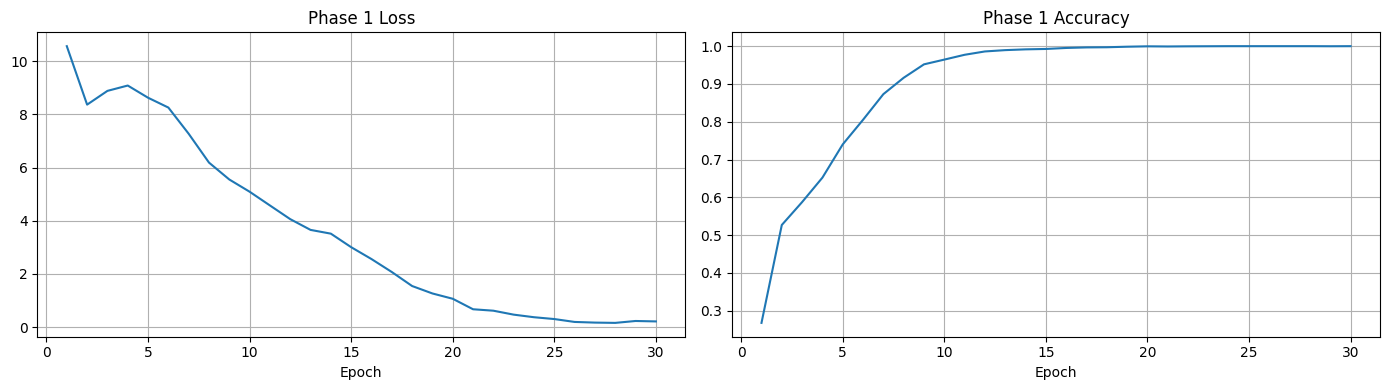

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
e1 = range(1, len(hist_p1['loss'])+1)
axes[0].plot(e1, hist_p1['loss']); axes[0].set_title('Phase 1 Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True)
axes[1].plot(e1, hist_p1['acc']);  axes[1].set_title('Phase 1 Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].grid(True)
plt.tight_layout(); plt.show()

---
## Section 7 -- Phase 2: Fine-Tuning (Frozen stem + layer1-3)

Freeze: `stem, layer1, layer2, layer3`. Trainable: `layer4, gem3, gem4, head, arc_head`.
Differential LR: backbone=2e-4, ArcFace=5e-4.


In [9]:
for name, p in backbone.named_parameters():
    p.requires_grad = not any(name.startswith(s) for s in ['stem.','layer1','layer2','layer3'])

n_frozen = sum(1 for p in backbone.parameters() if not p.requires_grad)
n_train  = sum(1 for p in backbone.parameters() if p.requires_grad)
print(f'Backbone -- Frozen: {n_frozen}  |  Trainable: {n_train}')
print('Frozen prefixes: stem (conv1+bn1), layer1, layer2, layer3')
print('Trainable      : layer4, gem3.p, gem4.p, head')

optimizer_p2 = torch.optim.Adam([
    {'params': [p for p in backbone.parameters() if p.requires_grad], 'lr': 2e-4},
    {'params': arc_head.parameters(), 'lr': 5e-4},
], weight_decay=1e-4)

sched_p2  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=N_P2, eta_min=1e-6)
params_p2 = [p for p in backbone.parameters() if p.requires_grad] + list(arc_head.parameters())
hist_p2   = {'loss':[], 'acc':[]}

for epoch in range(N_P2):
    loader_p2 = make_mining_loader(sample_loss_ema)
    backbone.train(); arc_head.train()
    ep_loss = 0.0; correct = 0; total = 0; n_batches = 0

    for imgs, labels, idxs in tqdm(loader_p2, desc=f'P2 {epoch+1:02d}/{N_P2}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        emb      = backbone(imgs)
        per_loss = arc_head(emb, labels, reduction='none')
        loss     = per_loss.mean()

        optimizer_p2.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params_p2, max_norm=1.0)
        optimizer_p2.step()

        with torch.no_grad():
            idxs_cpu = idxs.cpu()
            lv = per_loss.detach().cpu()
            sample_loss_ema[idxs_cpu] = 0.7 * sample_loss_ema[idxs_cpu] + 0.3 * lv
            cos_all = F.linear(F.normalize(emb,dim=1), F.normalize(arc_head.weight,dim=1))
            logits  = cos_all.view(-1, NUM_CLASSES, K_SUB).max(dim=2).values * arc_head.scale
            correct += (logits.argmax(1)==labels.long()).sum().item()
            total   += labels.size(0)
        ep_loss += loss.item(); n_batches += 1

    sched_p2.step()
    avg = ep_loss/n_batches; acc = correct/total
    hist_p2['loss'].append(avg); hist_p2['acc'].append(acc)
    print(f'P2 E{epoch+1:02d}/{N_P2}  loss={avg:.4f}  acc={acc:.3f}  lr={sched_p2.get_last_lr()[0]:.2e}')

Backbone -- Frozen: 87  |  Trainable: 27
Frozen prefixes: stem (conv1+bn1), layer1, layer2, layer3
Trainable      : layer4, gem3.p, gem4.p, head


P2 01/15:   0%|          | 0/77 [00:00<?, ?it/s]

P2 E01/15  loss=0.1658  acc=1.000  lr=1.98e-04


P2 02/15:   0%|          | 0/77 [00:00<?, ?it/s]

P2 E02/15  loss=0.1409  acc=1.000  lr=1.91e-04


...

P2 E13/15  loss=0.1360  acc=1.000  lr=9.60e-06


P2 14/15:   0%|          | 0/77 [00:00<?, ?it/s]

P2 E14/15  loss=0.2328  acc=1.000  lr=3.17e-06


P2 15/15:   0%|          | 0/77 [00:00<?, ?it/s]

P2 E15/15  loss=0.7800  acc=0.998  lr=1.00e-06


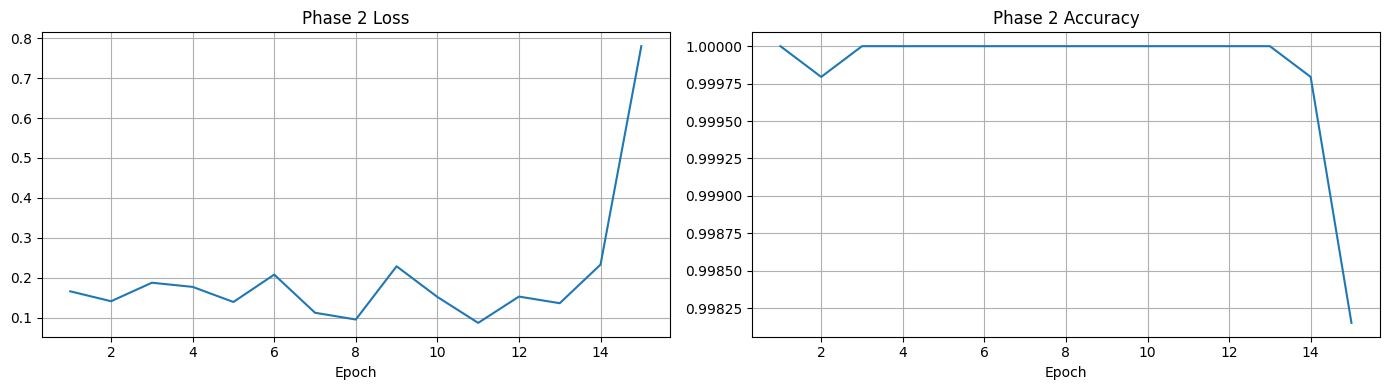

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
e2 = range(1, len(hist_p2['loss'])+1)
axes[0].plot(e2, hist_p2['loss']); axes[0].set_title('Phase 2 Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True)
axes[1].plot(e2, hist_p2['acc']);  axes[1].set_title('Phase 2 Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].grid(True)
plt.tight_layout(); plt.show()

---
## Section 8 -- Phase 3: Contrastive Fine-Tuning on Forgery Pairs

Uses genuine-forgery pairs from TRAINING writers only (GPDS150 + CEDAR training writers).
Loss: cosine contrastive with margin=0.4. Backbone unfrozen fully for this phase.


In [11]:
# Build Phase 3 dataset from training writers who have forgeries
df_for_p3 = pd.concat([df_gpds[df_gpds['writer_uid'].isin(gpds_train)],
                        df_cedar[df_cedar['writer_uid'].isin(cedar_train)]], ignore_index=True)
forg_ds_p3 = ForgeryPairDataset(df_for_p3, gpds_train | cedar_train, transform=train_tfm)
forg_ld_p3 = DataLoader(forg_ds_p3, batch_size=32, shuffle=True, num_workers=0)
print(f'Phase 3 pairs: {len(forg_ds_p3)}  (genuine-genuine + genuine-forgery)')

# Unfreeze all backbone parameters
for p in backbone.parameters(): p.requires_grad = True
params_p3    = list(backbone.parameters())
optimizer_p3 = torch.optim.Adam(params_p3, lr=5e-5, weight_decay=1e-4)
sched_p3     = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p3, T_max=N_P3, eta_min=1e-7)
hist_p3      = {'loss':[]}

for epoch in range(N_P3):
    backbone.train()
    ep_loss = 0.0; n_batches = 0
    for img_a, img_b, lbl in tqdm(forg_ld_p3, desc=f'P3 {epoch+1:02d}/{N_P3}', leave=False):
        img_a, img_b, lbl = img_a.to(DEVICE), img_b.to(DEVICE), lbl.to(DEVICE)
        e1 = backbone(img_a); e2 = backbone(img_b)
        loss = cosine_contrastive_loss(e1, e2, lbl, margin=0.4)
        optimizer_p3.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params_p3, max_norm=1.0)
        optimizer_p3.step()
        ep_loss += loss.item(); n_batches += 1
    sched_p3.step()
    avg = ep_loss / n_batches
    hist_p3['loss'].append(avg)
    print(f'P3 E{epoch+1:02d}/{N_P3}  contrastive_loss={avg:.4f}  lr={sched_p3.get_last_lr()[0]:.2e}')

Phase 3 pairs: 1716  (genuine-genuine + genuine-forgery)


P3 01/10:   0%|          | 0/54 [00:00<?, ?it/s]

P3 E01/10  contrastive_loss=0.0241  lr=4.88e-05


P3 02/10:   0%|          | 0/54 [00:00<?, ?it/s]

P3 E02/10  contrastive_loss=0.0202  lr=4.52e-05


...

P3 E08/10  contrastive_loss=0.0133  lr=4.87e-06


P3 09/10:   0%|          | 0/54 [00:00<?, ?it/s]

P3 E09/10  contrastive_loss=0.0128  lr=1.32e-06


P3 10/10:   0%|          | 0/54 [00:00<?, ?it/s]

P3 E10/10  contrastive_loss=0.0126  lr=1.00e-07


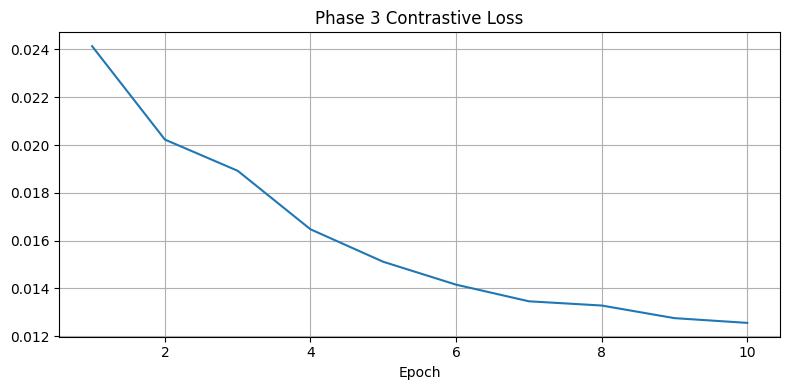

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(hist_p3['loss'])+1), hist_p3['loss'])
ax.set_title('Phase 3 Contrastive Loss'); ax.set_xlabel('Epoch'); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Section 9 -- Evaluation Helpers

`generate_pairs`: builds genuine-genuine (pos) + genuine-forgery (neg) pairs.
`extract_sims`: embeds all images and returns cosine similarities.
`run_eval`: calls both, prints EER + AUC, returns result dict.


In [13]:
def build_pools(df, wid_set):
    gen, forg = {}, {}
    for wid, grp in df[df['writer_uid'].isin(wid_set)].groupby('writer_uid'):
        g = grp[grp['label']=='genuine']['path'].tolist()
        f = grp[grp['label']=='forgery']['path'].tolist()
        if g: gen[wid]  = g
        if f: forg[wid] = f
    return gen, forg

def generate_pairs(df, wid_set, n_pairs=10000, seed=1, neg_mix=0.8):
    gen, forg = build_pools(df, wid_set)
    writers = sorted(gen); wf = sorted(set(gen) & set(forg))
    rng = np.random.default_rng(seed)
    n_pos = n_pairs // 2; n_neg = n_pairs - n_pos
    n_sf  = int(round(n_neg * neg_mix)); n_rnd = n_neg - n_sf
    rows = []
    for _ in range(n_pos):
        w = rng.choice(writers); g = gen[w]
        if len(g) < 2: continue
        i, j = rng.choice(len(g), size=2, replace=False)
        rows.append({'path_a':g[i],'path_b':g[j],'label':1,'pair_type':'pos'})
    for _ in range(n_sf):
        if not wf: break
        w = rng.choice(wf); g = gen[w]; f = forg[w]
        rows.append({'path_a':g[rng.integers(len(g))],'path_b':f[rng.integers(len(f))],'label':0,'pair_type':'neg_same'})
    for _ in range(n_rnd):
        if len(writers) < 2: break
        w1, w2 = rng.choice(writers, size=2, replace=False)
        rows.append({'path_a':gen[w1][rng.integers(len(gen[w1]))],'path_b':gen[w2][rng.integers(len(gen[w2]))],'label':0,'pair_type':'neg_cross'})
    return pd.DataFrame(rows)

def generate_hard_pairs(df, wid_set, n_pairs=5000, seed=2):
    gen, forg = build_pools(df, wid_set)
    wf  = sorted(set(gen) & set(forg))
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n_pairs // 2):
        if not wf: break
        w = rng.choice(wf); g = gen[w]
        if len(g) < 2: continue
        i, j = rng.choice(len(g), size=2, replace=False)
        rows.append({'path_a':g[i],'path_b':g[j],'label':1,'pair_type':'pos'})
    for _ in range(n_pairs // 2):
        if not wf: break
        w = rng.choice(wf); g = gen[w]; f = forg[w]
        rows.append({'path_a':g[rng.integers(len(g))],'path_b':f[rng.integers(len(f))],'label':0,'pair_type':'neg_same'})
    return pd.DataFrame(rows)

class PairDataset(Dataset):
    def __init__(self, pairs_df, transform): self.df = pairs_df.reset_index(drop=True); self.tfm = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        def load(p): img = Image.open(p).convert('L'); return self.tfm(img)
        return load(r['path_a']), load(r['path_b']), r['label']

def extract_sims(loader, backbone, device):
    backbone.eval(); sims, ys = [], []
    with torch.no_grad():
        for a, b, lbl in tqdm(loader, desc='embed', leave=False):
            ea = F.normalize(backbone(a.to(device)), dim=1)
            eb = F.normalize(backbone(b.to(device)), dim=1)
            sims.extend((ea * eb).sum(dim=1).cpu().tolist())
            ys.extend(lbl.tolist())
    return np.array(sims), np.array(ys)

_NAN_RES = {'eer': float('nan'), 'auc': float('nan'), 'accuracy': float('nan')}

def run_eval(name, df, test_wids, n_pairs=10000):
    """Generate pairs, embed, compute metrics, print results."""
    if not test_wids:
        print(f'\n=== {name}: SKIPPED (no test writers) ===')
        return _NAN_RES, _NAN_RES, float('nan'), np.array([]), np.array([])

    pairs_df = generate_pairs(df, test_wids, n_pairs=n_pairs, seed=1)
    if len(pairs_df) < 10:
        print(f'\n=== {name}: SKIPPED (only {len(pairs_df)} pairs generated -- insufficient data) ===')
        return _NAN_RES, _NAN_RES, float('nan'), np.array([]), np.array([])

    loader  = DataLoader(PairDataset(pairs_df, eval_tfm), batch_size=BATCH, shuffle=False, num_workers=0)
    sims, y = extract_sims(loader, backbone, DEVICE)
    res     = compute_metrics(y, sims)

    hard_df = generate_hard_pairs(df, test_wids, n_pairs=min(n_pairs//2, 3000), seed=2)
    if len(hard_df) < 10:
        print(f'  [hard-neg] skipped -- {len(hard_df)} pairs (test writers have no skilled forgeries)')
        res_hard = _NAN_RES
    else:
        hard_ld  = DataLoader(PairDataset(hard_df, eval_tfm), batch_size=BATCH, shuffle=False, num_workers=0)
        hs, hy   = extract_sims(hard_ld, backbone, DEVICE)
        res_hard = compute_metrics(hy, hs)

    gap = sims[y==1].mean() - sims[y==0].mean()
    print(f'\n=== {name} (n_test_writers={len(test_wids)}) ===')
    print(f'  Standard  EER={res["eer"]:.2%}  AUC={res["auc"]:.4f}  Acc={res["accuracy"]:.2%}  gap={gap:.4f}')
    if res_hard["eer"] == res_hard["eer"]:   # not NaN
        print(f'  Hard-neg  EER={res_hard["eer"]:.2%}  AUC={res_hard["auc"]:.4f}')
    else:
        print(f'  Hard-neg  SKIPPED (no skilled forgeries in test set)')
    return res, res_hard, gap, sims, y

---
## Section 10 -- CEDAR Test Evaluation

embed:   0%|          | 0/157 [00:00<?, ?it/s]

embed:   0%|          | 0/47 [00:00<?, ?it/s]


=== CEDAR (n_test_writers=11) ===
  Standard  EER=3.67%  AUC=0.9942  Acc=96.33%  gap=0.5154
  Hard-neg  EER=3.50%  AUC=0.9932


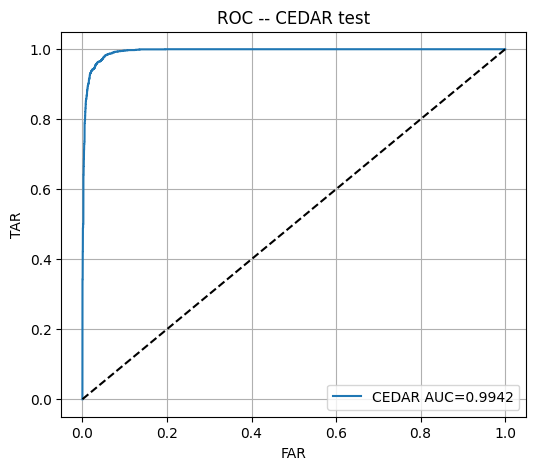

In [14]:
res_cedar, res_cedar_hard, gap_cedar, sims_cedar, y_cedar = run_eval(
    'CEDAR', df_cedar, cedar_test, n_pairs=10000
)
fpr_c, tpr_c, _ = sk_metrics.roc_curve(y_cedar, sims_cedar)
plt.figure(figsize=(6,5))
plt.plot(fpr_c, tpr_c, label=f'CEDAR AUC={res_cedar["auc"]:.4f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FAR'); plt.ylabel('TAR')
plt.title('ROC -- CEDAR test'); plt.legend(); plt.grid(True); plt.show()

---
## Section 11 -- GPDS150 Test Evaluation

embed:   0%|          | 0/157 [00:00<?, ?it/s]

embed:   0%|          | 0/47 [00:00<?, ?it/s]


=== GPDS150 (n_test_writers=30) ===
  Standard  EER=17.43%  AUC=0.9095  Acc=82.57%  gap=0.3619
  Hard-neg  EER=19.03%  AUC=0.8832


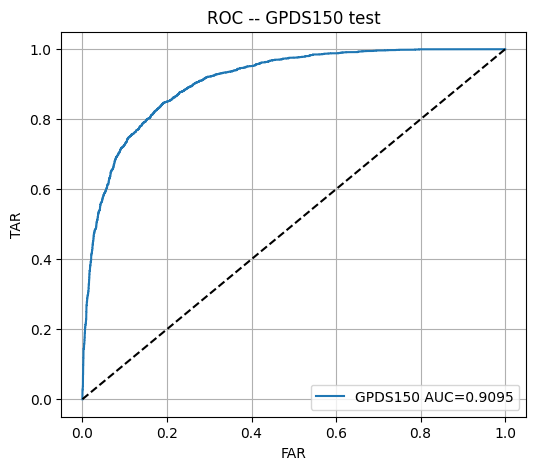

In [15]:
res_gpds, res_gpds_hard, gap_gpds, sims_gpds, y_gpds = run_eval(
    'GPDS150', df_gpds, gpds_test, n_pairs=10000
)
fpr_g, tpr_g, _ = sk_metrics.roc_curve(y_gpds, sims_gpds)
plt.figure(figsize=(6,5))
plt.plot(fpr_g, tpr_g, label=f'GPDS150 AUC={res_gpds["auc"]:.4f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FAR'); plt.ylabel('TAR')
plt.title('ROC -- GPDS150 test'); plt.legend(); plt.grid(True); plt.show()

---
## Section 12 -- SigComp2011 Test Evaluation

SigComp2011 test writers and their forgery counts:
  sc11c_009  genuine=24  forgery=0
  sc11c_103002  genuine=0  forgery=12
  sc11c_104006  genuine=0  forgery=11
  sc11c_108008  genuine=0  forgery=12
  sc11c_109005  genuine=0  forgery=10
  sc11c_110005  genuine=0  forgery=12
  sc11c_116002  genuine=0  forgery=12
  sc11c_116007  genuine=0  forgery=12
  sc11d_003  genuine=24  forgery=0
  sc11d_015  genuine=24  forgery=0
  sc11d_106015  genuine=0  forgery=4
  sc11d_123009  genuine=0  forgery=4
  sc11d_124004  genuine=0  forgery=4
  sc11d_126003  genuine=0  forgery=4
  sc11d_210015  genuine=0  forgery=4
  sc11d_213015  genuine=0  forgery=4


embed:   0%|          | 0/29 [00:00<?, ?it/s]

  [hard-neg] skipped -- 0 pairs (test writers have no skilled forgeries)

=== SigComp2011 (n_test_writers=16) ===
  Standard  EER=2.77%  AUC=0.9961  Acc=97.17%  gap=0.5676
  Hard-neg  SKIPPED (no skilled forgeries in test set)


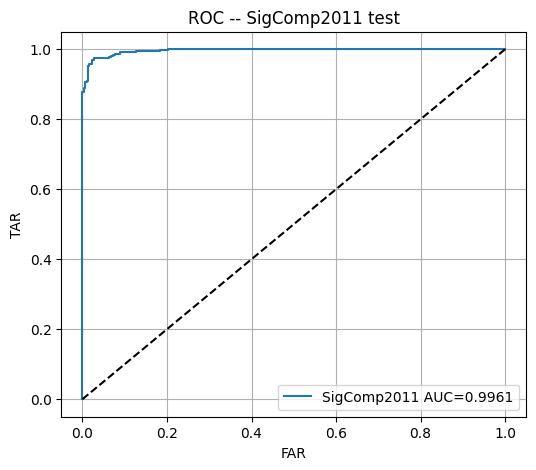

In [16]:
_NAN = float('nan')
_EMPTY_RES = {'eer':_NAN,'auc':_NAN,'accuracy':_NAN}

print('SigComp2011 test writers and their forgery counts:')
if not sc11_test:
    print('  (no test writers -- df_sc11 may be empty or path was not found)')
    print('  Check scanner output in Section 1 for the actual path error.')
    res_sc11 = res_sc11_hard = _EMPTY_RES
    gap_sc11 = _NAN
    sims_sc11 = np.array([]); y_sc11 = np.array([])
else:
    for wid in sorted(sc11_test):
        g = (df_sc11[(df_sc11['writer_uid']==wid)&(df_sc11['label']=='genuine')]).shape[0]
        f = (df_sc11[(df_sc11['writer_uid']==wid)&(df_sc11['label']=='forgery')]).shape[0]
        print(f'  {wid}  genuine={g}  forgery={f}')

    res_sc11, res_sc11_hard, gap_sc11, sims_sc11, y_sc11 = run_eval(
        'SigComp2011', df_sc11, sc11_test, n_pairs=3000
    )
    fpr_s, tpr_s, _ = sk_metrics.roc_curve(y_sc11, sims_sc11)
    plt.figure(figsize=(6,5))
    plt.plot(fpr_s, tpr_s, label=f'SigComp2011 AUC={res_sc11["auc"]:.4f}')
    plt.plot([0,1],[0,1],'k--'); plt.xlabel('FAR'); plt.ylabel('TAR')
    plt.title('ROC -- SigComp2011 test'); plt.legend(); plt.grid(True); plt.show()

---
## Section 13 -- Combined (Pooled) Evaluation

=== Combined (CEDAR + GPDS150 + SigComp2011) ===
  EER=11.01%  AUC=0.9580  Acc=88.99%  gap=0.4442
  Total pairs: 21,800


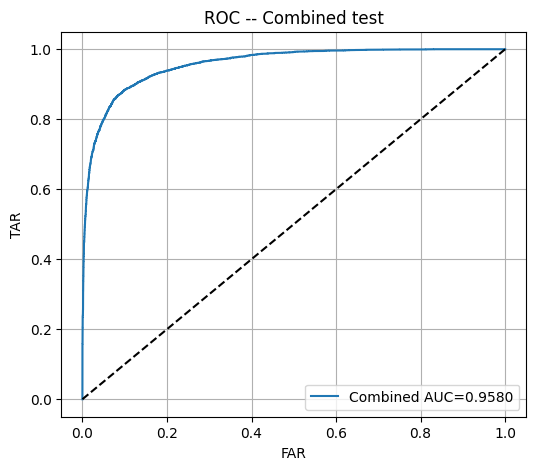

In [17]:
_parts_sims = [sims_cedar, sims_gpds] + ([sims_sc11] if len(sims_sc11) > 0 else [])
_parts_y    = [y_cedar,    y_gpds]    + ([y_sc11]    if len(y_sc11)    > 0 else [])
sims_all = np.concatenate(_parts_sims)
y_all    = np.concatenate(_parts_y)
res_combined = compute_metrics(y_all, sims_all)
gap_combined = sims_all[y_all==1].mean() - sims_all[y_all==0].mean()

print('=== Combined (CEDAR + GPDS150 + SigComp2011) ===')
print(f'  EER={res_combined["eer"]:.2%}  AUC={res_combined["auc"]:.4f}  '
      f'Acc={res_combined["accuracy"]:.2%}  gap={gap_combined:.4f}')
print(f'  Total pairs: {len(y_all):,}')

fpr_all, tpr_all, _ = sk_metrics.roc_curve(y_all, sims_all)
plt.figure(figsize=(6,5))
plt.plot(fpr_all, tpr_all, label=f'Combined AUC={res_combined["auc"]:.4f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FAR'); plt.ylabel('TAR')
plt.title('ROC -- Combined test'); plt.legend(); plt.grid(True); plt.show()

---
## Section 14 -- PCA: CEDAR Test Writers

PCA embed:   0%|          | 0/5 [00:00<?, ?it/s]

PCA explained variance: 33.81%


/tmp/ipykernel_408/1017896024.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab20', len(cedar_test))


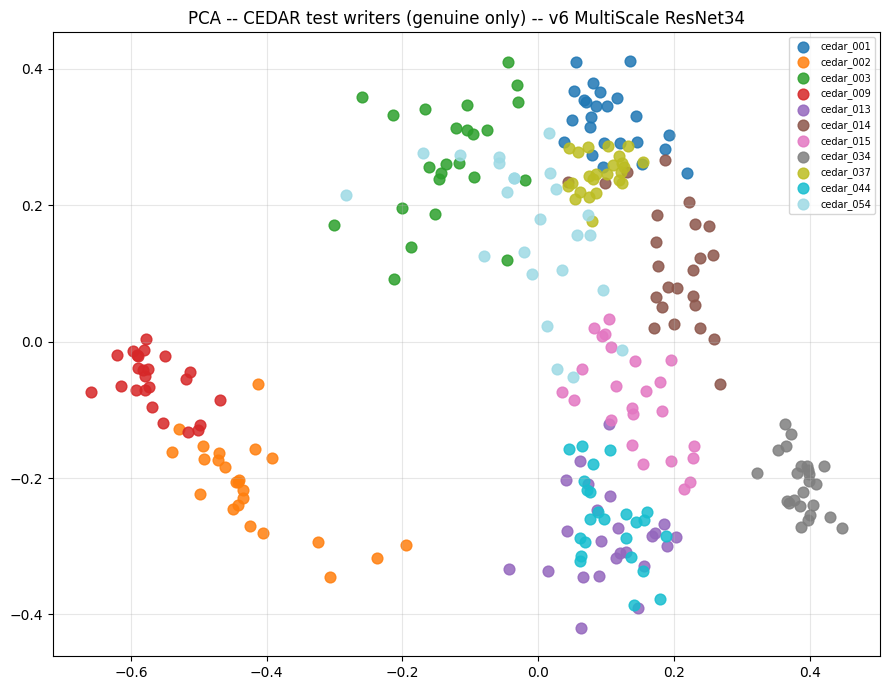

In [18]:
test_w2c   = {wid:i for i,wid in enumerate(sorted(cedar_test))}
test_gen   = SignatureClassDataset(None, test_w2c, cedar_test, transform=eval_tfm)
test_gen_l = DataLoader(test_gen, batch_size=BATCH, shuffle=False, num_workers=0)

backbone.eval()
all_e, all_w = [], []
with torch.no_grad():
    for imgs, cls, _ in tqdm(test_gen_l, desc='PCA embed', leave=False):
        all_e.append(F.normalize(backbone(imgs.to(DEVICE)),dim=1).cpu().numpy())
        all_w.append(cls.numpy())
all_e = np.concatenate(all_e); all_w = np.concatenate(all_w)

pca  = PCA(n_components=2, random_state=SEED)
e2d  = pca.fit_transform(all_e)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}')

fig, ax = plt.subplots(figsize=(9,7))
cmap    = plt.cm.get_cmap('tab20', len(cedar_test))
for i, wid in enumerate(sorted(test_w2c)):
    mask = all_w == test_w2c[wid]
    ax.scatter(e2d[mask,0], e2d[mask,1], color=cmap(i), label=wid, s=60, alpha=0.85)
ax.set_title('PCA -- CEDAR test writers (genuine only) -- v6 MultiScale ResNet34')
ax.legend(loc='best', fontsize=7); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Section 15 -- Results Summary

In [19]:
from IPython.display import Markdown, display

def fmt_row(name, res, res_hard, gap, n_writers):
    def f(v, fmt): return f'{v:{fmt}}' if v == v else 'N/A'   # nan check
    return (f'| {name:12s} | {n_writers:^13d} | {f(res["auc"],".4f")} | '
            f'{f(res["eer"],".2%")} | {f(res_hard["eer"],".2%")} | '
            f'{f(res["accuracy"],".2%")} | {f(gap,".4f")} |')

header = ('| Dataset | Test writers | AUC | EER (std) | EER (hard) | Accuracy | Cosine gap |\n'
          '|:--------|:------------:|----:|----------:|-----------:|---------:|-----------:|')

rows = '\n'.join([
    fmt_row('CEDAR',       res_cedar,    res_cedar_hard,  gap_cedar,    len(cedar_test)),
    fmt_row('GPDS150',     res_gpds,     res_gpds_hard,   gap_gpds,     len(gpds_test)),
    fmt_row('SigComp2011', res_sc11,     res_sc11_hard,   gap_sc11,     len(sc11_test)),
    fmt_row('Combined',    res_combined, res_combined,    gap_combined, len(cedar_test)+len(gpds_test)+len(sc11_test)),
])

display(Markdown(f'''
### v6 Results -- Multi-Dataset Evaluation (70/10/20 split)

{header}
{rows}

### Comparison with published work (CEDAR WI EER)
| Method | CEDAR WI EER | Year |
|:-------|:-----------:|------|
| MSDN region-based DML | 6.74% | 2021 |
| Signature Warping | 4.55% | 2022 |
| v4 ResNet18-PT (CEDAR only eval) | 7.91% | 2025 |
| **v6 (this run, CEDAR 20% test)** | **{res_cedar["eer"]:.2%}** | 2025 |

### Architecture: MultiScaleResNet34 + SubCenterArcFace K=3
- Backbone: ResNet34 pretrained ImageNet, grayscale (conv1 weight average)
- Pooling: GeM(layer3, 256-ch) + GeM(layer4, 512-ch) → concat 768-dim
- Head: BN(768) → Dropout(0.4) → Linear(256) → BN(256, affine=False)
- Loss: SubCenterArcFace K=3, margin curriculum 0.1→0.5
- Training: Phase1 (30ep) + Phase2 (15ep) + Phase3 contrastive (10ep)
- Training classes: {NUM_CLASSES}  (CEDAR+GPDS+SC11 train writers + all SC09)
'''))


### v6 Results -- Multi-Dataset Evaluation (70/10/20 split)

| Dataset | Test writers | AUC | EER (std) | EER (hard) | Accuracy | Cosine gap |
|:--------|:------------:|----:|----------:|-----------:|---------:|-----------:|
| CEDAR        |      11       | 0.9942 | 3.67% | 3.50% | 96.33% | 0.5154 |
| GPDS150      |      30       | 0.9095 | 17.43% | 19.03% | 82.57% | 0.3619 |
| SigComp2011  |      16       | 0.9961 | 2.77% | N/A | 97.17% | 0.5676 |
| Combined     |      57       | 0.9580 | 11.01% | 11.01% | 88.99% | 0.4442 |

### Comparison with published work (CEDAR WI EER)
| Method | CEDAR WI EER | Year |
|:-------|:-----------:|------|
| MSDN region-based DML | 6.74% | 2021 |
| Signature Warping | 4.55% | 2022 |
| v4 ResNet18-PT (CEDAR only eval) | 7.91% | 2025 |
| **v6 (this run, CEDAR 20% test)** | **3.67%** | 2025 |

### Architecture: MultiScaleResNet34 + SubCenterArcFace K=3
- Backbone: ResNet34 pretrained ImageNet, grayscale (conv1 weight average)
- Pooling: GeM(layer3, 256-ch) + GeM(layer4, 512-ch) → concat 768-dim
- Head: BN(768) → Dropout(0.4) → Linear(256) → BN(256, affine=False)
- Loss: SubCenterArcFace K=3, margin curriculum 0.1→0.5
- Training: Phase1 (30ep) + Phase2 (15ep) + Phase3 contrastive (10ep)
- Training classes: 242  (CEDAR+GPDS+SC11 train writers + all SC09)
